In [3]:
import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 9})
from sklearn.model_selection import train_test_split
# Neuroimaging
import ants

In [4]:
import sys
sys.path.append("../src/")

%load_ext autoreload
%autoreload 2
# Importing our custom module(s)
import ct
import mri
import utils

In [5]:
nifti_dir = "/cluster/tufts/hugheslab/datasets/OASIS-3_MRI"
scan_types = ["T1w", "T2w"]
condition = "AND"
labels_df = mri.label_oasis3(nifti_dir, scan_types, condition)
labels_df = labels_df[labels_df["paths"].apply(lambda paths: all(path != "" for path in paths))]
print(labels_df.shape)
print(len(labels_df[["Subject"]].value_counts()))
print(len(labels_df[["MR ID"]].value_counts()))
labels_df.head()

(1620, 38)
903
1620


,MR ID,Date_x,Subject,Age_x,Scanner,Scans,FreeSurfers,PUPs,scan_day,ADRC_ADRCCLINICALDATA ID,...,acsparnt,height,weight,primStudy,acsStudy,diagnosis_day,diff,abs_diff,Alzheimer's,paths
1,OAS30001_MR_d0129,NaN,OAS30001,65.0,3.0T,"bold(3), T1w(2), T2w(2)",1.0,NaN,129,OAS30001_ClinicalData_d0339,...,NaN,64.0,155.0,NaN,NaN,339,-210,210,0,[/cluster/tufts/hugheslab/datasets/OASIS-3_MRI...
14,OAS30001_MR_d0757,NaN,OAS30001,67.0,3.0T,"bold(2), dwi(1), minIP(1), swi(1), T1w(2), T2s...",1.0,NaN,757,OAS30001_ClinicalData_d0722,...,NaN,64.0,162.0,NaN,NaN,722,35,35,0,[/cluster/tufts/hugheslab/datasets/OASIS-3_MRI...
31,OAS30001_MR_d2430,NaN,OAS30001,71.0,3.0T,"angio(1), asl(1), dwi(2), fieldmap(3), FLAIR(1...",1.0,NaN,2430,OAS30001_ClinicalData_d2699,...,NaN,64.0,184.0,NaN,NaN,2699,-269,269,0,[/cluster/tufts/hugheslab/datasets/OASIS-3_MRI...
45,OAS30001_MR_d3132,NaN,OAS30001,73.0,3.0T,"asl(2), bold(2), dwi(2), fieldmap(3), T1w(1), ...",1.0,NaN,3132,OAS30001_ClinicalData_d3332,...,NaN,63.0,185.0,NaN,NaN,3332,-200,200,0,[/cluster/tufts/hugheslab/datasets/OASIS-3_MRI...
58,OAS30001_MR_d3746,NaN,OAS30001,NaN,NaN,"angio(1), asl(1), bold(2), fieldmap(3), FLAIR(...",1.0,NaN,3746,OAS30001_ClinicalData_d3675,...,NaN,64.0,192.0,NaN,NaN,3675,71,71,0,[/cluster/tufts/hugheslab/datasets/OASIS-3_MRI...


(176, 256, 256)


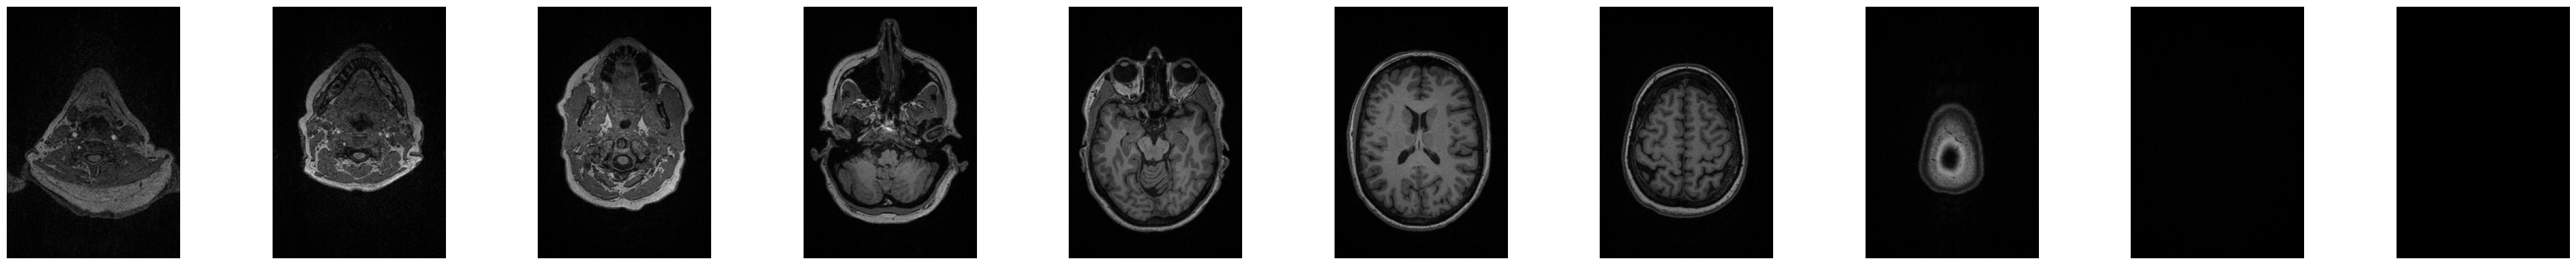

In [6]:
image = ants.image_read(labels_df.iloc[0].paths[0]).numpy()
print(image.shape)
linspace = np.linspace(0, image.shape[-1] - 1, 10).astype(int)

ncols, nrows = 10, 1
fig, axs = plt.subplots(ncols=ncols, nrows=nrows, figsize=(4*ncols,4*nrows))

for i, j in enumerate(linspace):
    axs[i].imshow(np.rot90(image[:,:,j], k=1, axes=(-2, -1)), cmap='gray', vmin=np.min(image), vmax=np.max(image))
    axs[i].set_axis_off()
    
fig.tight_layout()
plt.show()

In [7]:
numpy_dir = '/cluster/tufts/hugheslab/datasets/OASIS-3_MRI_numpy'
starts = np.linspace(0, 1620, num=11).astype(int)[:-1]
stops = np.linspace(0, 1620, num=11).astype(int)[1:]
for start, stop in zip(starts, stops):
    print(f'    "python ../src/preprocess_oasis-3_mri.py --condition=\'AND\' --nifti_dir=\'{nifti_dir}\' --numpy_dir=\'{numpy_dir}\' --scan_type \'T1w\' \'T2w\' --start={start} --stop={stop}"')

    "python ../src/preprocess_oasis-3_mri.py --condition='AND' --nifti_dir='/cluster/tufts/hugheslab/datasets/OASIS-3_MRI' --numpy_dir='/cluster/tufts/hugheslab/datasets/OASIS-3_MRI_numpy' --scan_type 'T1w' 'T2w' --start=0 --stop=162"
    "python ../src/preprocess_oasis-3_mri.py --condition='AND' --nifti_dir='/cluster/tufts/hugheslab/datasets/OASIS-3_MRI' --numpy_dir='/cluster/tufts/hugheslab/datasets/OASIS-3_MRI_numpy' --scan_type 'T1w' 'T2w' --start=162 --stop=324"
    "python ../src/preprocess_oasis-3_mri.py --condition='AND' --nifti_dir='/cluster/tufts/hugheslab/datasets/OASIS-3_MRI' --numpy_dir='/cluster/tufts/hugheslab/datasets/OASIS-3_MRI_numpy' --scan_type 'T1w' 'T2w' --start=324 --stop=486"
    "python ../src/preprocess_oasis-3_mri.py --condition='AND' --nifti_dir='/cluster/tufts/hugheslab/datasets/OASIS-3_MRI' --numpy_dir='/cluster/tufts/hugheslab/datasets/OASIS-3_MRI_numpy' --scan_type 'T1w' 'T2w' --start=486 --stop=648"
    "python ../src/preprocess_oasis-3_mri.py --conditi

In [8]:
labels_df['path'] = labels_df['MR ID'].apply(lambda mr_id: f'{numpy_dir}/{mr_id}.npz')
#labels_df.to_csv(f'{numpy_dir}/labels.csv', index=False)
labels_df.head()

,MR ID,Date_x,Subject,Age_x,Scanner,Scans,FreeSurfers,PUPs,scan_day,ADRC_ADRCCLINICALDATA ID,...,height,weight,primStudy,acsStudy,diagnosis_day,diff,abs_diff,Alzheimer's,paths,path
1,OAS30001_MR_d0129,NaN,OAS30001,65.0,3.0T,"bold(3), T1w(2), T2w(2)",1.0,NaN,129,OAS30001_ClinicalData_d0339,...,64.0,155.0,NaN,NaN,339,-210,210,0,[/cluster/tufts/hugheslab/datasets/OASIS-3_MRI...,/cluster/tufts/hugheslab/datasets/OASIS-3_MRI_...
14,OAS30001_MR_d0757,NaN,OAS30001,67.0,3.0T,"bold(2), dwi(1), minIP(1), swi(1), T1w(2), T2s...",1.0,NaN,757,OAS30001_ClinicalData_d0722,...,64.0,162.0,NaN,NaN,722,35,35,0,[/cluster/tufts/hugheslab/datasets/OASIS-3_MRI...,/cluster/tufts/hugheslab/datasets/OASIS-3_MRI_...
31,OAS30001_MR_d2430,NaN,OAS30001,71.0,3.0T,"angio(1), asl(1), dwi(2), fieldmap(3), FLAIR(1...",1.0,NaN,2430,OAS30001_ClinicalData_d2699,...,64.0,184.0,NaN,NaN,2699,-269,269,0,[/cluster/tufts/hugheslab/datasets/OASIS-3_MRI...,/cluster/tufts/hugheslab/datasets/OASIS-3_MRI_...
45,OAS30001_MR_d3132,NaN,OAS30001,73.0,3.0T,"asl(2), bold(2), dwi(2), fieldmap(3), T1w(1), ...",1.0,NaN,3132,OAS30001_ClinicalData_d3332,...,63.0,185.0,NaN,NaN,3332,-200,200,0,[/cluster/tufts/hugheslab/datasets/OASIS-3_MRI...,/cluster/tufts/hugheslab/datasets/OASIS-3_MRI_...
58,OAS30001_MR_d3746,NaN,OAS30001,NaN,NaN,"angio(1), asl(1), bold(2), fieldmap(3), FLAIR(...",1.0,NaN,3746,OAS30001_ClinicalData_d3675,...,64.0,192.0,NaN,NaN,3675,71,71,0,[/cluster/tufts/hugheslab/datasets/OASIS-3_MRI...,/cluster/tufts/hugheslab/datasets/OASIS-3_MRI_...


In [10]:
np.round(np.linspace(0, 178, num=5)).astype(int)[1:-1]

array([ 44,  89, 134])

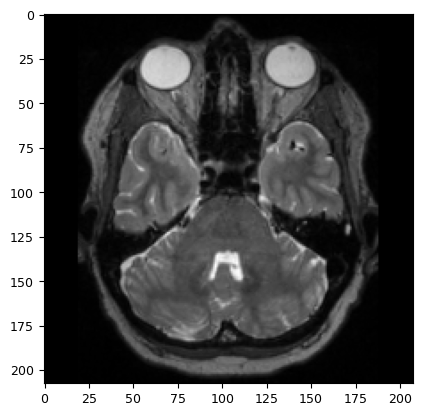

In [30]:
image = np.load(labels_df.iloc[0].path)["arr_0"]
image = np.rot90(image[1, :, :, 44], k=1)
s = max(image.shape)
image = np.pad(
    image,
    (((max(image.shape) - image.shape[0])//2, max(image.shape) - image.shape[0] - (max(image.shape) - image.shape[0])//2),
     ((max(image.shape) - image.shape[1])//2, max(image.shape) - image.shape[1] - (max(image.shape) - image.shape[1])//2)),
    mode="constant",
    constant_values=image.min(),
)

plt.imshow(image, cmap="gray", vmin=image.min(), vmax=image.max())


In [27]:
image[1,:,:,44].shape

(169, 208)

(2, 169, 208, 179)


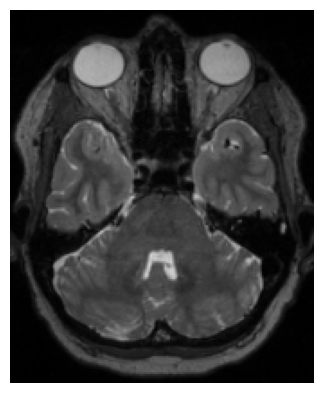

In [18]:
image = np.load(labels_df.iloc[0].path)["arr_0"]
print(image.shape)

fig, ax = plt.subplots(figsize=(4*ncols,4*nrows), ncols=1, nrows=1)

ax.imshow(np.rot90(image[1,:,:,44], k=1, axes=(-2, -1)), cmap='gray', vmin=np.min(image[1]), vmax=np.max(image[1]))
ax.set_axis_off()
    
fig.tight_layout()
fig.savefig("example_mri_t2_44.pdf", bbox_inches="tight")
plt.show()